## REGULARIZATION & HYPERPARAMETER TUNING

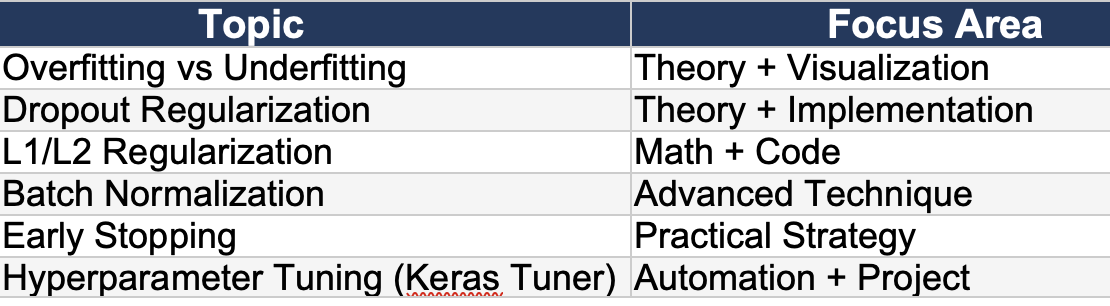

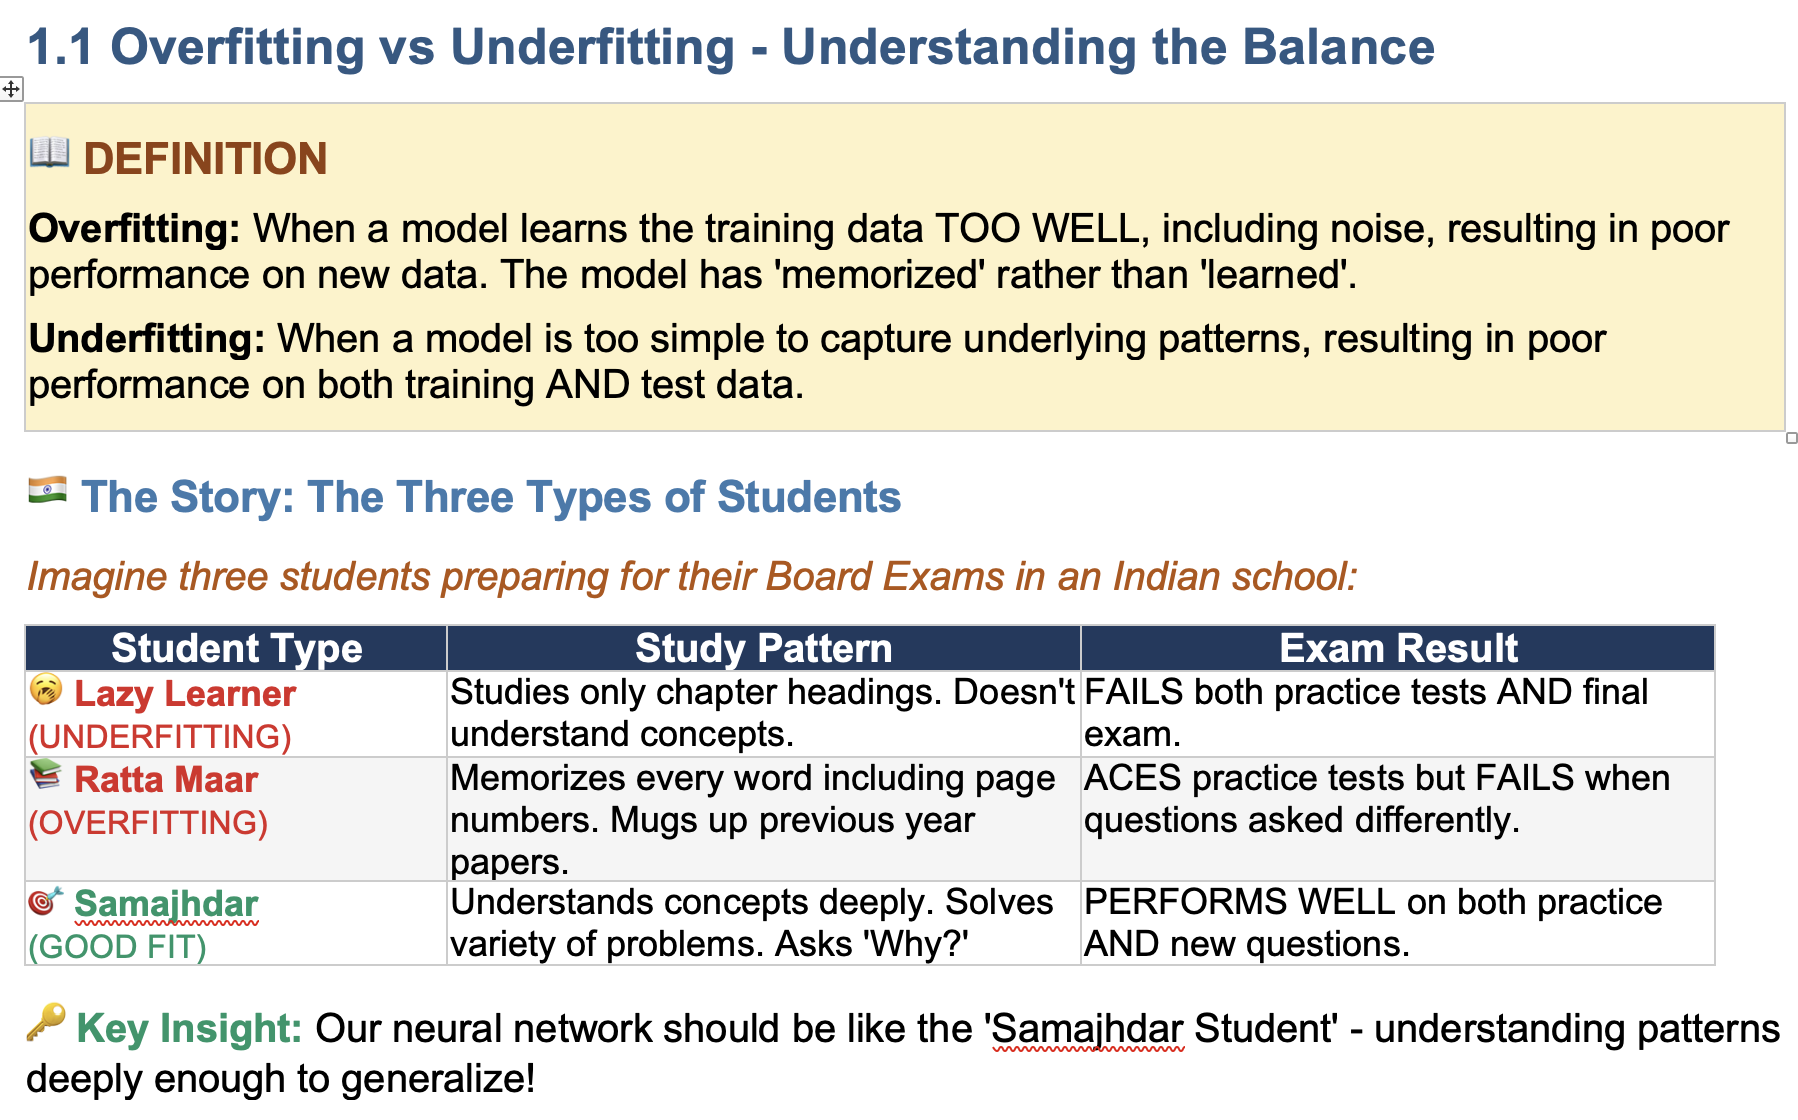

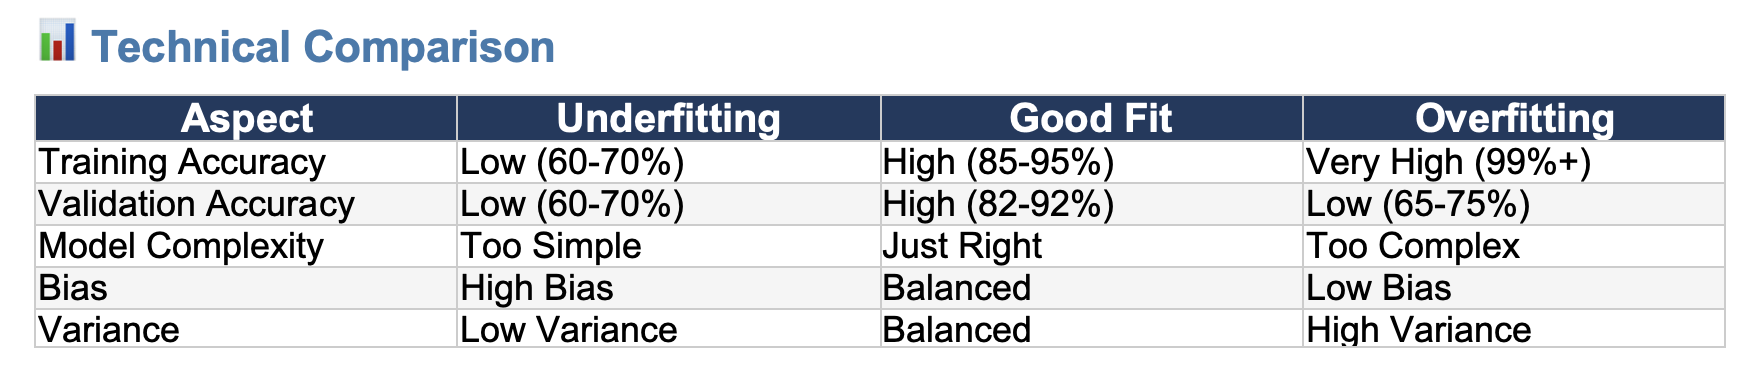

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1, l2, l1_l2
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


/opt/homebrew/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# =============================================================================
# EXAMPLE 1: DETECTING OVERFITTING VS UNDERFITTING (🟢 EASY)
# Indian Analogy: Three Types of Students
# =============================================================================
print("\n" + "=" * 60)
print("EXAMPLE 1: DETECTING OVERFITTING VS UNDERFITTING")
print("Indian Analogy: The Three Types of Students")
print("=" * 60)

# Generate sample data (Moon dataset - like two chapatis!)
print("\n📊 Generating Moon Dataset...")
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X_train_moon, X_val_moon, y_train_moon, y_val_moon = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples: {len(X_train_moon)}, Validation samples: {len(X_val_moon)}")


EXAMPLE 1: DETECTING OVERFITTING VS UNDERFITTING
Indian Analogy: The Three Types of Students

📊 Generating Moon Dataset...
Training samples: 400, Validation samples: 100


In [3]:
# MODEL 1: UNDERFITTING (Too Simple - Lazy Student / आलसी विद्यार्थी)
print("\n🥱 Creating UNDERFITTING Model (Lazy Student)...")
underfit_model = keras.Sequential([
    layers.Dense(2, activation='relu', input_shape=(2,)),  # Too few neurons!
    layers.Dense(1, activation='sigmoid')
], name='Underfit_Lazy_Student')



🥱 Creating UNDERFITTING Model (Lazy Student)...


/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# MODEL 2: OVERFITTING (Too Complex - Ratta Maar / रट्टा मार)
print("📚 Creating OVERFITTING Model (Ratta Maar)...")
overfit_model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(2,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(256, activation='relu'),  # Way too many neurons!
    layers.Dense(1, activation='sigmoid')
], name='Overfit_Ratta_Maar')

📚 Creating OVERFITTING Model (Ratta Maar)...


In [5]:
# MODEL 3: GOOD FIT (Just Right - Samajhdar / समझदार विद्यार्थी)
print("🎯 Creating GOOD FIT Model (Samajhdar Student)...")
goodfit_model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(2,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name='GoodFit_Samajhdar')

🎯 Creating GOOD FIT Model (Samajhdar Student)...


In [6]:
# Compile all models
for model in [underfit_model, overfit_model, goodfit_model]:
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )


In [7]:
# Train and capture history
print("\n🏋️ Training all three models...")
history_under = underfit_model.fit(
    X_train_moon, y_train_moon,
    validation_data=(X_val_moon, y_val_moon),
    epochs=100, verbose=0
)

history_over = overfit_model.fit(
    X_train_moon, y_train_moon,
    validation_data=(X_val_moon, y_val_moon),
    epochs=100, verbose=0
)

history_good = goodfit_model.fit(
    X_train_moon, y_train_moon,
    validation_data=(X_val_moon, y_val_moon),
    epochs=100, verbose=0
)


🏋️ Training all three models...


In [8]:
# Visualization function
def plot_learning_curves(history, title, ax1, ax2):
    """Plot training vs validation loss and accuracy"""
    # Plot Loss
    ax1.plot(history.history['loss'], 'b-', label='Training Loss', linewidth=2)
    ax1.plot(history.history['val_loss'], 'r--', label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss Curves')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot Accuracy
    ax2.plot(history.history['accuracy'], 'b-', label='Training Acc', linewidth=2)
    ax2.plot(history.history['val_accuracy'], 'r--', label='Validation Acc', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} - Accuracy Curves')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

# Create visualization
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

plot_learning_curves(history_under, 'UNDERFITTING (Lazy Student)', axes[0, 0], axes[0, 1])
plot_learning_curves(history_over, 'OVERFITTING (Ratta Maar)', axes[1, 0], axes[1, 1])
plot_learning_curves(history_good, 'GOOD FIT (Samajhdar)', axes[2, 0], axes[2, 1])

plt.tight_layout()
plt.savefig('Day09_Example1_Overfitting_Detection.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ Visualization saved: Day09_Example1_Overfitting_Detection.png")


✅ Visualization saved: Day09_Example1_Overfitting_Detection.png


In [9]:
# Print results
print("\n📊 RESULTS COMPARISON:")
print("-" * 50)
print(f"{'Model':<25} {'Train Acc':<15} {'Val Acc':<15}")
print("-" * 50)
print(f"{'Underfit (Lazy)':<25} {history_under.history['accuracy'][-1]:.4f}         {history_under.history['val_accuracy'][-1]:.4f}")
print(f"{'Overfit (Ratta Maar)':<25} {history_over.history['accuracy'][-1]:.4f}         {history_over.history['val_accuracy'][-1]:.4f}")
print(f"{'Good Fit (Samajhdar)':<25} {history_good.history['accuracy'][-1]:.4f}         {history_good.history['val_accuracy'][-1]:.4f}")


📊 RESULTS COMPARISON:
--------------------------------------------------
Model                     Train Acc       Val Acc        
--------------------------------------------------
Underfit (Lazy)           0.8550         0.8500
Overfit (Ratta Maar)      0.9875         0.9600
Good Fit (Samajhdar)      0.9825         0.9800


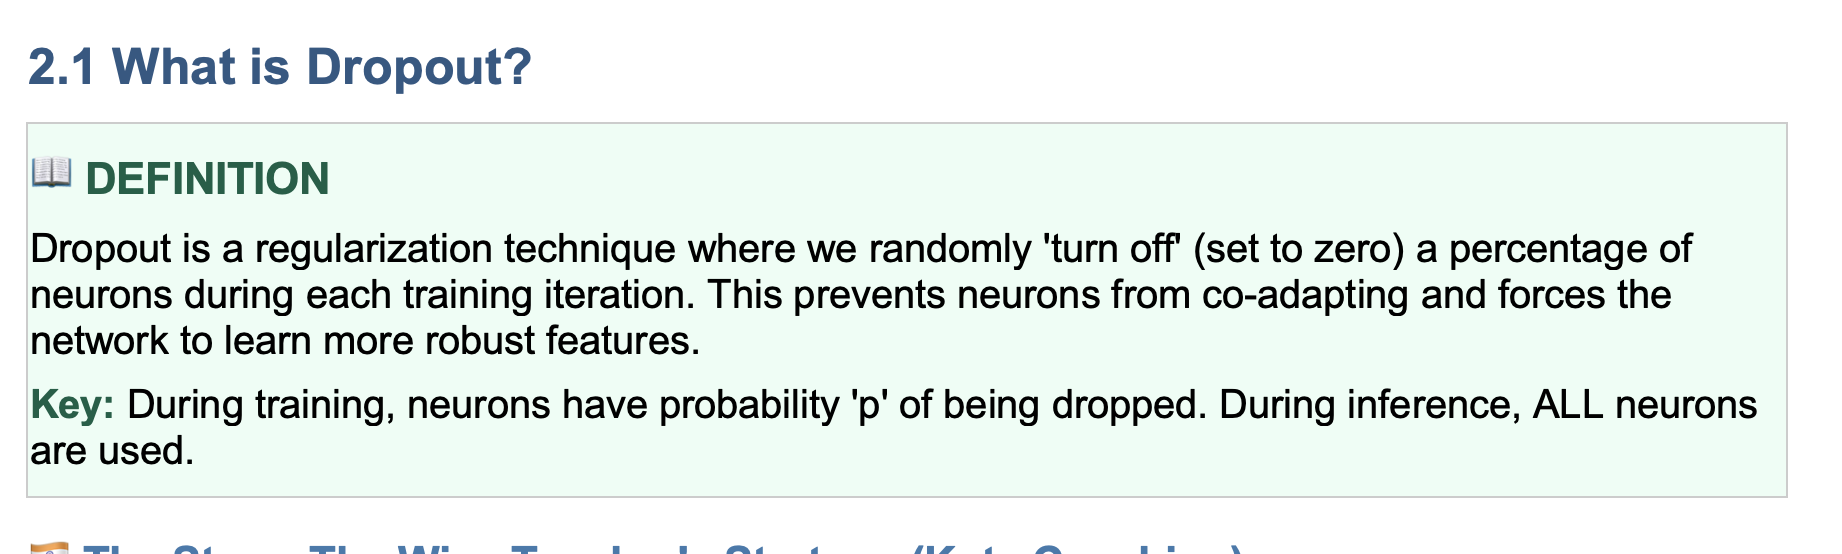

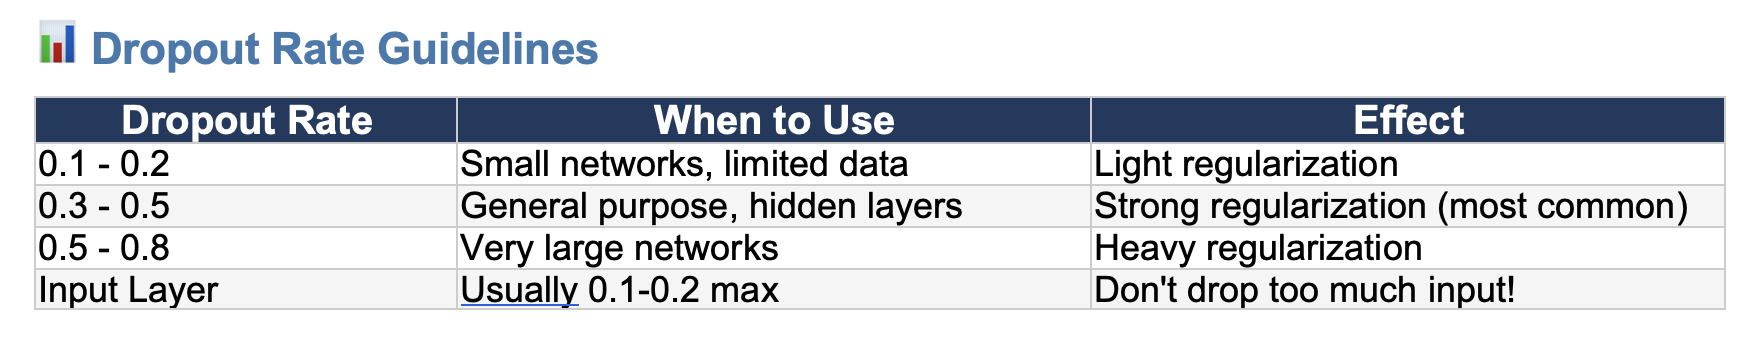

In [5]:
# =============================================================================
# EXAMPLE 2: DROPOUT REGULARIZATION (🟡 MEDIUM)
# Indian Analogy: Kota Coaching Strategy
# =============================================================================
print("\n" + "=" * 60)
print("EXAMPLE 2: DROPOUT REGULARIZATION")
print("Indian Analogy: Sharma Sir's Kota Coaching Strategy")
print("=" * 60)

# Load MNIST dataset
print("\n📊 Loading MNIST Dataset...")
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Preprocess - Normalize to 0-1 range
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 784).astype('float32') / 255.0

print(f"Training samples: {len(X_train_flat)}, Test samples: {len(X_test_flat)}")


EXAMPLE 2: DROPOUT REGULARIZATION
Indian Analogy: Sharma Sir's Kota Coaching Strategy

📊 Loading MNIST Dataset...
Training samples: 60000, Test samples: 10000


In [11]:
# MODEL WITHOUT DROPOUT (Prone to Overfitting - All students always present)
print("\n❌ Creating Model WITHOUT Dropout...")
model_no_dropout = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='No_Dropout')


❌ Creating Model WITHOUT Dropout...


In [12]:
# MODEL WITH DROPOUT (Regularized - Sharma Sir's Strategy)
print("✅ Creating Model WITH Dropout (Sharma Sir's Strategy)...")
model_with_dropout = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),  # 30% students absent each day
    
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),  # Different students absent
    
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),  # Everyone learns independently!
    
    layers.Dense(10, activation='softmax')  # Exam day - all present
], name='With_Dropout')

✅ Creating Model WITH Dropout (Sharma Sir's Strategy)...


In [13]:
# Compile both models
for model in [model_no_dropout, model_with_dropout]:
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

# Train both models
print("\n🏋️ Training Model WITHOUT Dropout...")
history_no_drop = model_no_dropout.fit(
    X_train_flat, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    verbose=0
)
print("🏋️ Training Model WITH Dropout...")
history_with_drop = model_with_dropout.fit(
    X_train_flat, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    verbose=0
)


🏋️ Training Model WITHOUT Dropout...
🏋️ Training Model WITH Dropout...


In [14]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Without Dropout
axes[0].plot(history_no_drop.history['loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(history_no_drop.history['val_loss'], 'r--', label='Val Loss', linewidth=2)
axes[0].set_title('WITHOUT Dropout - All Students Always Present', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# With Dropout
axes[1].plot(history_with_drop.history['loss'], 'b-', label='Train Loss', linewidth=2)
axes[1].plot(history_with_drop.history['val_loss'], 'r--', label='Val Loss', linewidth=2)
axes[1].set_title('WITH Dropout - Sharma Sir Strategy', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Day09_Example2_Dropout_Comparison.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ Visualization saved: Day09_Example2_Dropout_Comparison.png")

✅ Visualization saved: Day09_Example2_Dropout_Comparison.png


In [15]:
# Evaluate on test set
print("\n📊 TEST SET RESULTS:")
print("-" * 50)
test_loss_no, test_acc_no = model_no_dropout.evaluate(X_test_flat, y_test, verbose=0)
test_loss_with, test_acc_with = model_with_dropout.evaluate(X_test_flat, y_test, verbose=0)
print(f"Without Dropout: {test_acc_no*100:.2f}% accuracy")
print(f"With Dropout:    {test_acc_with*100:.2f}% accuracy")


📊 TEST SET RESULTS:
--------------------------------------------------
Without Dropout: 98.08% accuracy
With Dropout:    98.26% accuracy


## L1/L2 REGULARIZATION

    No Regularization
        Unlimited Fund
            Anything
    L1 (Lasso)
        Imported Flowers    =>  0
        Guest               =>  0
    L2  (Ridge)
        Imported Flower     =>  50Lac   =>  10%
        Guest               =>  1CR     =>  10%
    Elastic Net

In [16]:
# =============================================================================
# EXAMPLE 3: L1/L2 REGULARIZATION (🔴 HARD)
# Indian Analogy: Wedding Budget Planner
# =============================================================================
print("\n" + "=" * 60)
print("EXAMPLE 3: L1/L2 REGULARIZATION")
print("Indian Analogy: Big Fat Indian Wedding Budget")
print("=" * 60)


EXAMPLE 3: L1/L2 REGULARIZATION
Indian Analogy: Big Fat Indian Wedding Budget


In [17]:
# L1 Regularized Model (Sparse - Cut unnecessary wedding items completely)
print("\n✂️ Creating L1 Model (Cut unnecessary items - ₹0 for extras)...")
model_l1 = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,),
                kernel_regularizer=l1(0.001)),
    layers.Dense(128, activation='relu',
                kernel_regularizer=l1(0.001)),
    layers.Dense(10, activation='softmax')
], name='L1_Wedding_Cutter')


✂️ Creating L1 Model (Cut unnecessary items - ₹0 for extras)...


In [18]:
# L2 Regularized Model (Weight Decay - Reduce all proportionally)
print("📉 Creating L2 Model (Reduce everything proportionally)...")
model_l2 = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,),
                kernel_regularizer=l2(0.001)),
    layers.Dense(128, activation='relu',
                kernel_regularizer=l2(0.001)),
    layers.Dense(10, activation='softmax')
], name='L2_Wedding_Reducer')

📉 Creating L2 Model (Reduce everything proportionally)...


In [20]:
# Elastic Net (Best of Both Worlds - Smart Planner)
print("🎯 Creating Elastic Net Model (Smart planner - best of both)...")
model_elastic = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,),
                kernel_regularizer=l1_l2(l1=0.0005, l2=0.0005)),
    layers.Dense(128, activation='relu',
                kernel_regularizer=l1_l2(l1=0.0005, l2=0.0005)),
    layers.Dense(10, activation='softmax')
], name='ElasticNet_Smart_Planner')

🎯 Creating Elastic Net Model (Smart planner - best of both)...


In [24]:
784*256

200704

In [26]:
256*128

32768

In [21]:
# Compile and train
for model in [model_l1, model_l2, model_elastic]:
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

In [22]:
print("\n🏋️ Training L1, L2, and Elastic Net models...")
history_l1 = model_l1.fit(X_train_flat, y_train, validation_split=0.2, epochs=15, batch_size=128, verbose=0)
history_l2 = model_l2.fit(X_train_flat, y_train, validation_split=0.2, epochs=15, batch_size=128, verbose=0)
history_elastic = model_elastic.fit(X_train_flat, y_train, validation_split=0.2, epochs=15, batch_size=128, verbose=0)


🏋️ Training L1, L2, and Elastic Net models...


In [25]:
#  Analyze weight sparsity
def analyze_weights(model, name):
    """Count zero and near-zero weights"""
    total_weights = 0
    zero_weights = 0
    near_zero = 0  # |w| < 0.01
    
    for layer in model.layers:
        weights = layer.get_weights()
        if len(weights) > 0:
            w = weights[0].flatten()
            total_weights += len(w)
            zero_weights += np.sum(w == 0)
            near_zero += np.sum(np.abs(w) < 0.01)
    
    return {
        'name': name,
        'total': total_weights,
        'zero': zero_weights,
        'near_zero': near_zero,
        'zero_pct': 100 * zero_weights / total_weights,
        'near_zero_pct': 100 * near_zero / total_weights
    }

print("\n📊 WEIGHT SPARSITY ANALYSIS:")
print("-" * 60)
for model, name in [(model_l1, 'L1 (Cutter)'), (model_l2, 'L2 (Reducer)'), (model_elastic, 'Elastic (Smart)')]:
    stats = analyze_weights(model, name)
    print(f"{name}: {stats['zero_pct']:.1f}% weights zero")
    print(f"{name}: {stats['near_zero_pct']:.1f}% weights near zero")


📊 WEIGHT SPARSITY ANALYSIS:
------------------------------------------------------------
L1 (Cutter): 0.0% weights zero
L1 (Cutter): 98.6% weights near zero
L2 (Reducer): 0.0% weights zero
L2 (Reducer): 77.4% weights near zero
Elastic (Smart): 0.0% weights zero
Elastic (Smart): 98.0% weights near zero


    Input
    Hidden 1    =>  x y z
    Hidden 2    =>  p q r
    Hidden 3    =>  p x a
    Output

    Sugar   =>  2
    Milk    =>
    Tea     =>
    Water   =>  


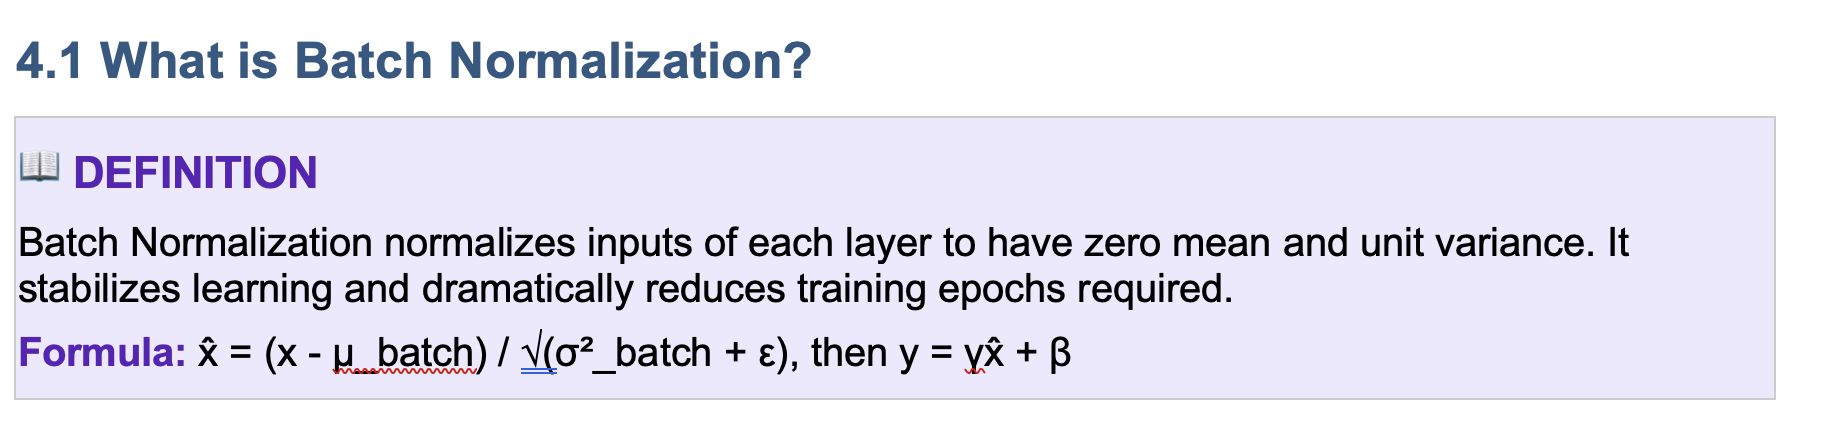

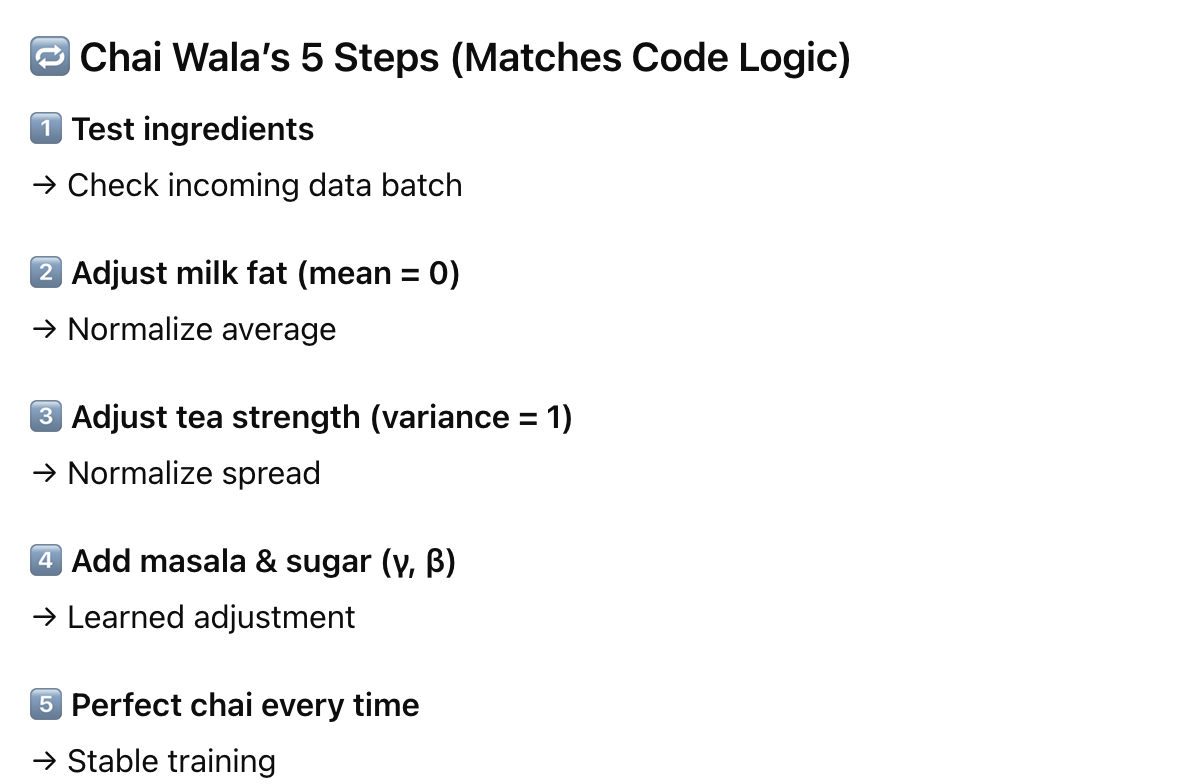

In [18]:
#  =============================================================================
# EXAMPLE 4: BATCH NORMALIZATION (🟡 MEDIUM)
# Indian Analogy: Chai Wala's Secret
# =============================================================================
print("\n" + "=" * 60)
print("EXAMPLE 4: BATCH NORMALIZATION")
print("Indian Analogy: The Famous Delhi Chai Wala's Secret")
print("=" * 60)

# Model WITHOUT BatchNorm (Inconsistent ingredients)
print("\n❌ Creating Model WITHOUT BatchNorm (Inconsistent Chai)...")
model_no_bn = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='No_BatchNorm')


EXAMPLE 4: BATCH NORMALIZATION
Indian Analogy: The Famous Delhi Chai Wala's Secret

❌ Creating Model WITHOUT BatchNorm (Inconsistent Chai)...


In [19]:
# Model WITH BatchNorm (Chai Wala's standardization)
print("✅ Creating Model WITH BatchNorm (Perfect Chai Every Time)...")
model_with_bn = keras.Sequential([
    # Layer 1: Dense -> BatchNorm -> Activation
    layers.Dense(512, input_shape=(784,)),  # No activation here!
    layers.BatchNormalization(),             # Standardize ingredients
    layers.Activation('relu'),               # Then process
    
    # Layer 2
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    
    # Layer 3
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    
    # Output (No BatchNorm before softmax!)
    layers.Dense(10, activation='softmax')
], name='With_BatchNorm')

✅ Creating Model WITH BatchNorm (Perfect Chai Every Time)...


In [20]:
# Compile - BatchNorm allows higher learning rate!
model_no_bn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_with_bn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),  # 10x higher!
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🏋️ Training both models...")
history_no_bn = model_no_bn.fit(X_train_flat, y_train, validation_split=0.2, epochs=10, batch_size=128, verbose=0)
history_with_bn = model_with_bn.fit(X_train_flat, y_train, validation_split=0.2, epochs=10, batch_size=128, verbose=0)


🏋️ Training both models...


In [21]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_no_bn.history['accuracy'], 'b-', label='Train', linewidth=2)
axes[0].plot(history_no_bn.history['val_accuracy'], 'r--', label='Val', linewidth=2)
axes[0].set_title('WITHOUT BatchNorm (Inconsistent Chai)', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_with_bn.history['accuracy'], 'b-', label='Train', linewidth=2)
axes[1].plot(history_with_bn.history['val_accuracy'], 'r--', label='Val', linewidth=2)
axes[1].set_title('WITH BatchNorm (Perfect Chai - 10x Learning Rate!)', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Day09_Example4_BatchNorm_Comparison.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ Visualization saved: Day09_Example4_BatchNorm_Comparison.png")

✅ Visualization saved: Day09_Example4_BatchNorm_Comparison.png


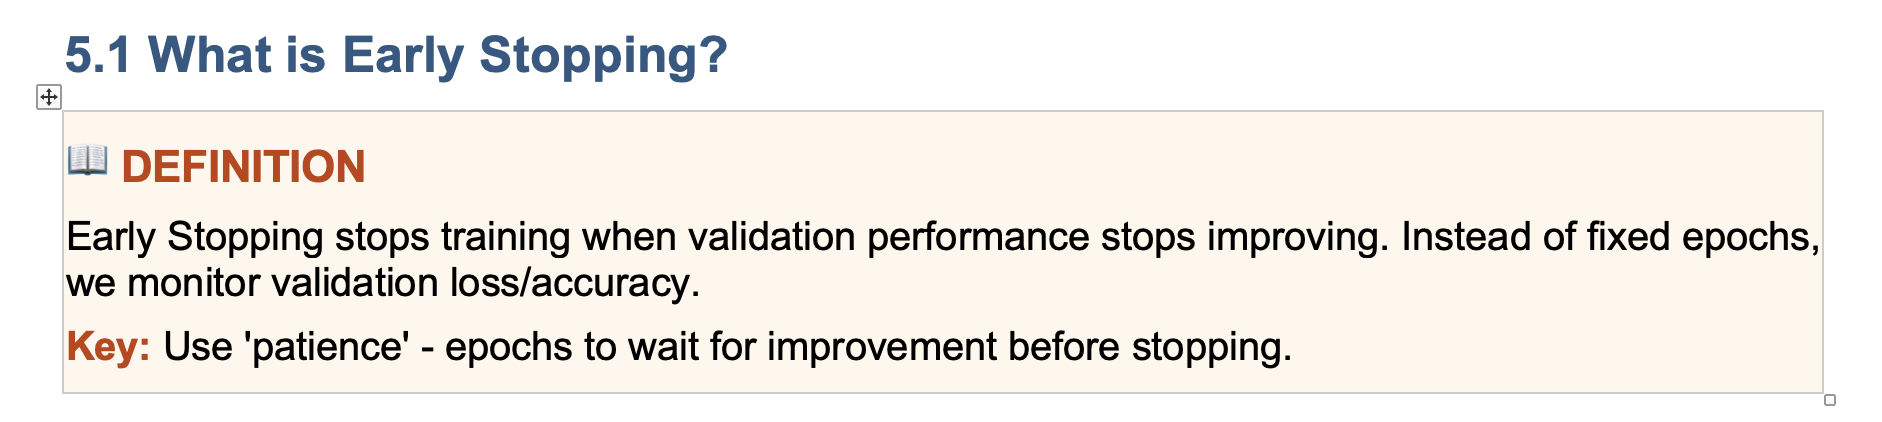

In [22]:
# =============================================================================
# EXAMPLE 5: EARLY STOPPING (🟢 EASY)
# Indian Analogy: Perfect Gulab Jamun
# =============================================================================
print("\n" + "=" * 60)
print("EXAMPLE 5: EARLY STOPPING")
print("Indian Analogy: Deep Frying the Perfect Gulab Jamun")
print("=" * 60)

# Create Early Stopping callback (The wise cook's timer)
early_stopping = EarlyStopping(
    monitor='val_loss',           # Watch validation loss (check color)
    patience=10,                  # Wait 10 epochs for improvement
    min_delta=0.001,              # Minimum change to count as improvement
    mode='min',                   # 'min' because lower loss is better
    restore_best_weights=True,    # Go back to golden brown moment!
    verbose=1
)


EXAMPLE 5: EARLY STOPPING
Indian Analogy: Deep Frying the Perfect Gulab Jamun


In [23]:
# Model Checkpoint (Save the perfect moment)
model_checkpoint = ModelCheckpoint(
    'best_gulab_jamun_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [24]:
# Reduce Learning Rate on Plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # Reduce LR by half
    patience=5,           # Wait 5 epochs before reducing
    min_lr=1e-6,          # Don't go below this
    verbose=1
)

In [25]:
#  Build model
print("\n🍬 Creating Gulab Jamun Model...")
model_early = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
], name='Gulab_Jamun_Model')

model_early.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train with callbacks
print("\n🔥 Deep frying (training) with Early Stopping...")
print("   Set epochs=100, but Early Stopping will find the perfect moment!")
history_early = model_early.fit(
    X_train_flat, y_train,
    validation_split=0.2,
    epochs=100,  # High number - early stopping handles it
    batch_size=128,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)


🍬 Creating Gulab Jamun Model...

🔥 Deep frying (training) with Early Stopping...
   Set epochs=100, but Early Stopping will find the perfect moment!

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 8.


In [27]:
print(f"\n✅ Training stopped at epoch {len(history_early.history['loss'])}")
print(f"   Best validation loss: {min(history_early.history['val_loss']):.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
epochs_range = range(1, len(history_early.history['loss']) + 1)
ax.plot(epochs_range, history_early.history['loss'], 'b-', label='Training Loss', linewidth=2)
ax.plot(epochs_range, history_early.history['val_loss'], 'r--', label='Validation Loss', linewidth=2)
ax.axvline(x=np.argmin(history_early.history['val_loss']) + 1, color='g', linestyle=':', label='Best Epoch', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Early Stopping - Golden Brown Gulab Jamun Moment 🍬', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Day09_Example5_Early_Stopping.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ Visualization saved: Day09_Example5_Early_Stopping.png")



✅ Training stopped at epoch 18
   Best validation loss: 0.0747
✅ Visualization saved: Day09_Example5_Early_Stopping.png


/var/folders/yd/f8xyzv517m153dvsb8f9rggh0000gn/T/ipykernel_11200/2375550395.py:16: UserWarning: Glyph 127852 (\N{CANDY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yd/f8xyzv517m153dvsb8f9rggh0000gn/T/ipykernel_11200/2375550395.py:17: UserWarning: Glyph 127852 (\N{CANDY}) missing from font(s) DejaVu Sans.
  plt.savefig('Day09_Example5_Early_Stopping.png', dpi=150, bbox_inches='tight')


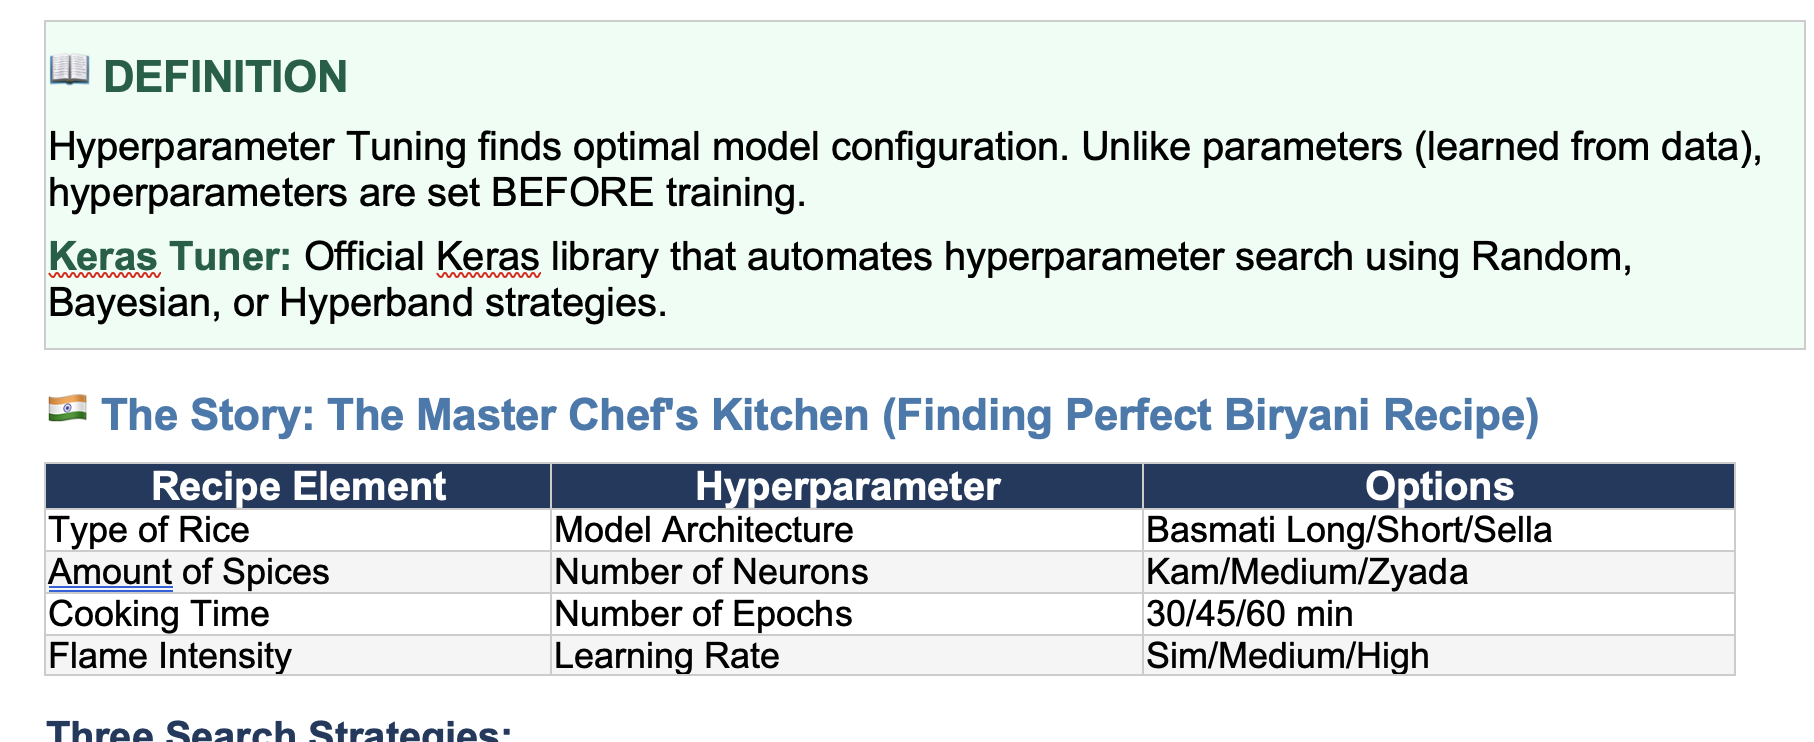

In [8]:

# =============================================================================
# EXAMPLE 6: KERAS TUNER - HYPERPARAMETER OPTIMIZATION (💀 CRAZY HARD)
# Indian Analogy: Master Chef's Kitchen - Finding Perfect Biryani Recipe
# =============================================================================
print("\n" + "=" * 60)
print("EXAMPLE 6: HYPERPARAMETER TUNING")
print("Indian Analogy: Master Chef Finding Perfect Biryani Recipe")
print("=" * 60)

try:
    import keras_tuner as kt
    
    def build_tunable_model(hp):
        """
        Build a model with tunable hyperparameters.
        Like a Master Chef experimenting with different:
        - Rice types (architecture)
        - Spice amounts (neurons)
        - Cooking time (epochs)
        - Flame intensity (learning rate)
        """
        model = keras.Sequential()
        model.add(layers.Input(shape=(784,)))
        
        # Tune number of layers (1 to 3)
        for i in range(hp.Int('num_layers', 1, 3)):
            # Tune number of neurons
            model.add(layers.Dense(
                units=hp.Int(f'units_{i}', min_value=64, max_value=256, step=64),
                activation='relu'
            ))
            
            # Tune whether to use BatchNorm
            if hp.Boolean(f'batch_norm_{i}'):
                model.add(layers.BatchNormalization())
            
            # Tune dropout rate
            dropout_rate = hp.Float(f'dropout_{i}', 0.0, 0.5, step=0.1)
            if dropout_rate > 0:
                model.add(layers.Dropout(dropout_rate))
        
        model.add(layers.Dense(10, activation='softmax'))
        
        # Tune learning rate
        learning_rate = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
        
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        return model
    
    print("\n👨‍🍳 Creating Keras Tuner (Master Chef)...")
    
    # Create Random Search tuner
    tuner = kt.RandomSearch(
        build_tunable_model,
        objective='val_accuracy',
        max_trials=10,  # Reduced for demo
        executions_per_trial=1,
        directory='img/',
        project_name='mnist_biryani_recipe'
    )
    
    # Show search space
    print("\n📋 Search Space Summary:")
    tuner.search_space_summary()
    
    # Create early stopping for tuner
    early_stop_tuner = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
    
    # Run the search
    print("\n🔍 Searching for the Perfect Recipe...")
    tuner.search(
        X_train_flat[:10000], y_train[:10000],  # Use subset for speed
        validation_split=0.2,
        epochs=10,
        callbacks=[early_stop_tuner],
        verbose=1
    )
    
    # Get best hyperparameters
    print("\n" + "=" * 50)
    print("🏆 BEST RECIPE FOUND!")
    print("=" * 50)
    
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    print(f"Number of layers: {best_hps.get('num_layers')}")
    print(f"Learning rate: {best_hps.get('learning_rate')}")
    
    for i in range(best_hps.get('num_layers')):
        print(f"Layer {i+1}: {best_hps.get(f'units_{i}')} neurons, "
              f"BatchNorm={best_hps.get(f'batch_norm_{i}')}, "
              f"Dropout={best_hps.get(f'dropout_{i}')}")
    
    # Build and train the best model
    best_model = tuner.hypermodel.build(best_hps)
    print("\n📊 Best Model Summary:")
    best_model.summary()
    
except ImportError:
    print("\n⚠️ keras-tuner not installed. Install with: pip install keras-tuner")
    print("   Skipping hyperparameter tuning example.")


Trial 16 Complete [00h 00m 11s]
val_accuracy: 0.9424999952316284

Best val_accuracy So Far: 0.9520000219345093
Total elapsed time: 00h 03m 12s

🏆 BEST RECIPE FOUND!
Number of layers: 1
Learning rate: 0.001
Layer 1: 256 neurons, BatchNorm=True, Dropout=0.4

📊 Best Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,554 (799.04 KB)

 Trainable params: 204,042 (797.04 KB)

 Non-trainable params: 512 (2.00 KB)